<a href="https://colab.research.google.com/github/mehakmakkar/COMP331-Project/blob/main/AnomalyDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install kagglehub

In [34]:
# Imports

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score


In [24]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
file_name = 'creditcard.csv'

df = pd.read_csv(f'{path}/{file_name}')
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [25]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# Analysing Amount v/s Class

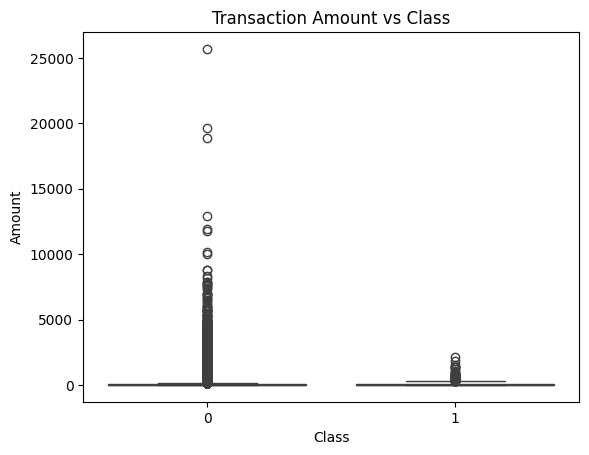

In [26]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount vs Class')
plt.show()

As we can see, it's hard to decode patterns due to extreme outliers, especially in the non-fraudulent class.

In fact, a key insight here is that most high amount transactions don't appear to be in fraudulent transactions.

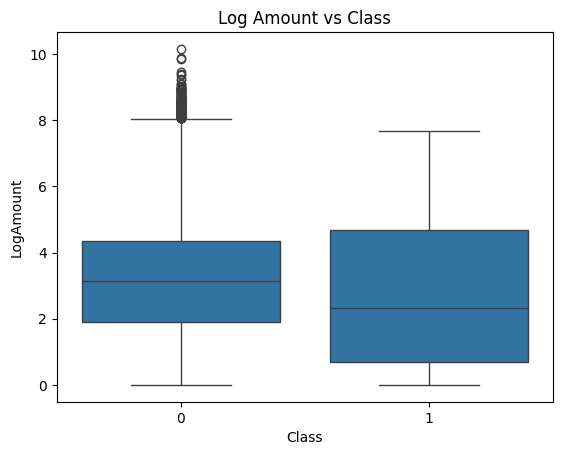

In [28]:
# Log scaled box plot to show patterns

df['LogAmount'] = np.log1p(df['Amount'])

sns.boxplot(x='Class', y='LogAmount', data=df)
plt.title('Log Amount vs Class')
plt.show()

With log-scaled box-plots we can see that fraudulent class has bigger inter quartile range. The fraudulent transactions are smaller in amount and have high variability.

# Anomlay detection

## 1 Statistical Analysis

### 1.1 Z-Score Analysis

In [33]:
df["z_score_amount"] = zscore(df["Amount"])

threshold = 3
df["zscore_pred"] = np.where(np.abs(df["z_score_amount"]) > threshold, 1, 0)

print(classification_report(df["Class"], df["zscore_pred"]))

print("\nNumber of anomalies detected by Z-score:", df["zscore_pred"].sum())
print("Actual number of fraud cases:", df["Class"].sum())

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    284315
           1       0.00      0.02      0.00       492

    accuracy                           0.98    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      0.98      0.99    284807


Number of anomalies detected by Z-score: 4076
Actual number of fraud cases: 492


In the above classification report, we can observe the accuracy and f1-score of the z-score analysis. In this case, we're detecting the outliers that are more than 3 standard deviations for the Amount and marking any outliers as fraudulent.

This is very misleading and a dangerous technique in this case for several reasons:

1. Based on our previous analysis, we already established that most fraudulent transactions happen at the median range. They're unlikely to occur at the outlier amount.

2. Based on the f1-score we've achieved a 0.99 meaning our approach has a high success rate. But like a skewed model that has very minimal fraudulent transactions, this is misleading. If we look at the f1-score of the fraud-class, we have an f1-score of 0.

3. Same with accuracy. While it looks like we have achieved 98% accuracy, it's solely because we've marked every transaction as legit and that's true for majority of the situation anyways.

## 2. Machine Learning Classification

In [35]:
# Data Preparation for training

## Features and target
X = df.drop(columns=['Class'])
y = df['Class']

## Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### 2.1. K-Nearest Neighbours

In [ ]:
# We'll loop through 1 to 30 neighbours to see where the f1-score for fraud class
# is highest

k_values = list(range(1, 31, 2))
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    f1 = f1_score(y_test, y_pred)

    f1_scores.append(f1)

In [ ]:
# KNN Accuracy Plot

plt.figure()
plt.plot(k_values, f1_scores, marker='o')
plt.xlabel('K')
plt.ylabel('F1 Score')
plt.title('KNN F1 Score vs K')
plt.grid()
plt.show()

### 2.2. Linear Discriminant Analysis

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Predictions
y_pred = lda.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("LDA Accuracy:", acc)


In [ ]:
# LDA Plot

plt.figure()
plt.bar(['LDA'], [acc])
plt.ylabel('Accuracy')
plt.title('LDA Accuracy')
plt.show()

### 2.3 Logistic Regression

In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", acc)

## 3. Unsupervised Learning

### 3.1 Isolation Forest

In [ ]:
X_train_normal = X_train[y_train == 0]

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.0017,   # about fraud ratio in this dataset
    random_state=42
)

y_pred_if = iso_forest.predict(X_test)
y_pred_if = np.where(y_pred_if == -1, 1, 0)

# Evaluation
print("F1 Score:", f1_score(y_test, y_pred_if))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_if))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_if))

### 3.2 K-Means Clustering

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# KMeans model (2 clusters: normal vs fraud)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)

# Predict clusters
clusters = kmeans.predict(X_test)

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clusters Visualization')

plt.colorbar(scatter, label='Cluster')
plt.show()